#   EDA: `players`

**Descripción:** Lista de usuarios de Steam con su país de residencia y fecha de creación de cuenta.

| Columna | Tipo | Descripción |
|---|---|---|
| `playerid` | int | ID único del usuario en Steam |
| `country` | str | País de residencia del usuario |
| `created` | datetime | Fecha y hora de creación del perfil |

---

##  Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes, ha='center', fontsize=9, color=MUTED)

## Carga y exploración inicial

In [2]:
df_raw = pd.read_csv('Datos/players.csv')
print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)

Shape: 424,683 filas × 3 columnas


,playerid,country,created
0,76561198287452552,Brazil,2016-03-02 06:14:20
1,76561198040436563,Israel,2011-04-10 17:10:06
2,76561198049686270,NaN,2011-09-28 21:43:59
3,76561198155814250,Kazakhstan,2014-09-24 19:52:47
4,76561198119605821,NaN,2013-12-26 00:25:50


In [3]:
print(df_raw.dtypes)
print("\nEstadísticas básicas:")
df_raw.describe(include='all')

playerid     int64
country     object
created     object
dtype: object

Estadísticas básicas:


,playerid,country,created
count,4.246830e+05,246815,377014
unique,NaN,249,376781
top,NaN,United States,2012-01-09 14:06:15
freq,NaN,29808,8
mean,7.656120e+16,NaN,NaN
std,3.995359e+08,NaN,NaN
min,7.656120e+16,NaN,NaN
25%,7.656120e+16,NaN,NaN
50%,7.656120e+16,NaN,NaN
75%,7.656120e+16,NaN,NaN


---
##  Análisis y tratamiento de valores faltantes




In [4]:
missing = df_raw.isnull() | (df_raw.apply(lambda col: col.astype(str).str.strip() == ''))
miss_pct = (missing.mean() * 100).round(2)

print("Porcentaje de faltantes por columna:")
print(miss_pct.to_string())

both_missing    = (df_raw['country'].isna() & df_raw['created'].isna()).sum()
only_country    = (df_raw['country'].isna() & df_raw['created'].notna()).sum()
only_created    = (df_raw['country'].notna() & df_raw['created'].isna()).sum()

print(f"\nAmbos faltantes (country + created) : {both_missing:,}")
print(f"Solo country faltante               : {only_country:,}")
print(f"Solo created faltante               : {only_created:,}")

Porcentaje de faltantes por columna:
playerid     0.00
country     41.88
created     11.22

Ambos faltantes (country + created) : 47,669
Solo country faltante               : 130,199
Solo created faltante               : 0


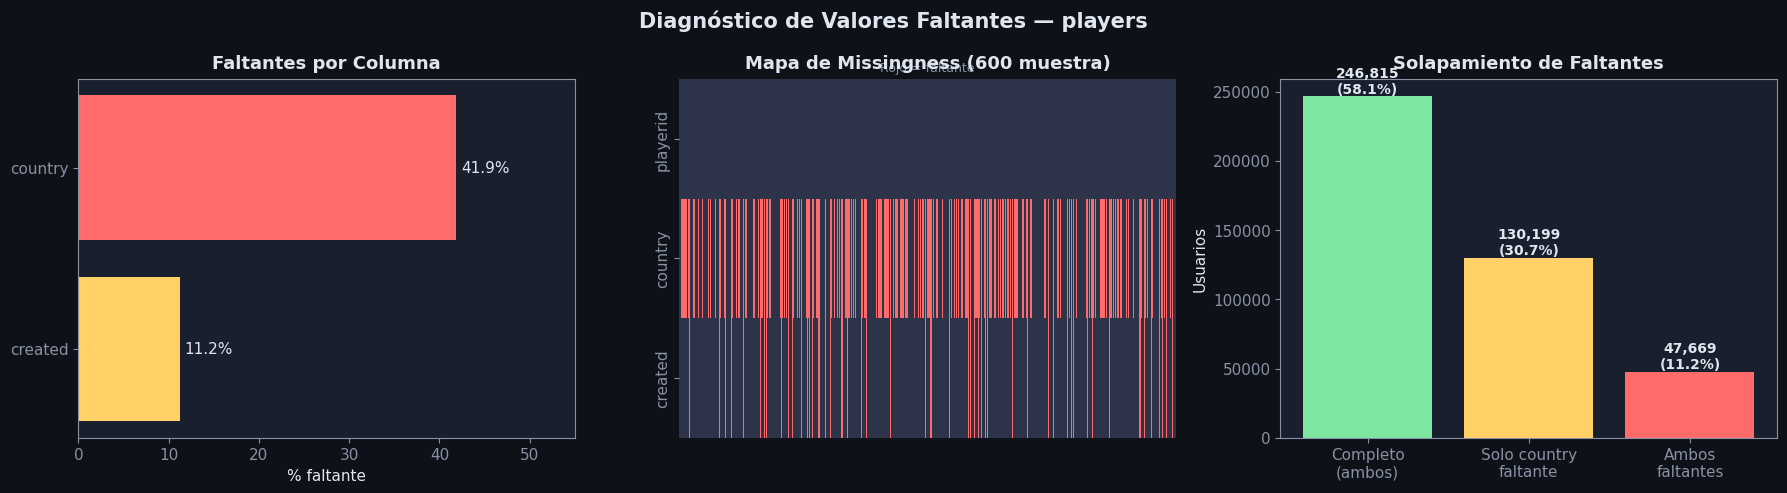

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — players', fontsize=15, fontweight='bold', color=TEXT)

ax = axes[0]
cols_m = miss_pct[miss_pct > 0].sort_values()
bars = ax.barh(cols_m.index, cols_m.values,
               color=[ACCENT3 if v > 30 else ACCENT4 for v in cols_m.values])
for bar, val in zip(bars, cols_m.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color=TEXT, fontsize=11)
ax.set_xlim(0, 55)
ax.set_xlabel('% faltante')
title_ax(ax, 'Faltantes por Columna')

ax = axes[1]
sample = df_raw.sample(min(600, len(df_raw)), random_state=42)
miss_m = sample.isnull() | (sample.apply(lambda col: col.astype(str).str.strip() == ''))
sns.heatmap(miss_m.T, ax=ax, cbar=False,
            cmap=['#2d3348', ACCENT3], yticklabels=True, xticklabels=False)
title_ax(ax, 'Mapa de Missingness (600 muestra)', 'Rojo = faltante')

ax = axes[2]
complete    = (df_raw['country'].notna() & df_raw['created'].notna()).sum()
lbls = ['Completo\n(ambos)', 'Solo country\nfaltante', 'Ambos\nfaltantes']
vals = [complete, only_country, both_missing]
colors = [ACCENT2, ACCENT4, ACCENT3]
ax.bar(lbls, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(i, v + 2000, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
            ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax.set_ylabel('Usuarios')
title_ax(ax, 'Solapamiento de Faltantes')

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()
df['created'] = pd.to_datetime(df['created'], errors='coerce')

df = df.dropna(subset=['created']).reset_index(drop=True)

df['country'] = df['country'].fillna('Unknown')

df['created_year']  = df['created'].dt.year
df['created_month'] = df['created'].dt.month
df['created_dow']   = df['created'].dt.dayofweek
df['created_hour']  = df['created'].dt.hour

print(f"Original  : {df_raw.shape[0]:,} filas")
print(f"Eliminadas: {df_raw.shape[0] - len(df):,} filas (created NaN)")
print(f"Limpio    : {len(df):,} filas")
print(f"Country 'Unknown': {(df['country']=='Unknown').sum():,} ({(df['country']=='Unknown').mean()*100:.1f}%)")
print("\nFaltantes después del tratamiento:")
print(df.isnull().sum())

try:
    df_private = pd.read_csv('Datos/private_steamids.csv')
    private_set = set(df_private['playerid'].tolist())
    df['is_private'] = df['playerid'].isin(private_set)

    unknown_mask = df['country'] == 'Unknown'
    n_priv = (unknown_mask & df['is_private']).sum()
    n_pub  = (unknown_mask & ~df['is_private']).sum()
    print(f'Country Unknown + privado : {n_priv:,}  ({n_priv/unknown_mask.sum()*100:.1f}% de los Unknown)')
    print(f'Country Unknown + público : {n_pub:,}  ({n_pub/unknown_mask.sum()*100:.1f}% de los Unknown)')
    print(f'Usuarios is_private=True  : {df["is_private"].sum():,}  ({df["is_private"].mean()*100:.1f}%)')
except FileNotFoundError:
    print(' private_steamids.csv no encontrado — is_private no calculado.')
    df['is_private'] = False


Original  : 424,683 filas
Eliminadas: 47,669 filas (created NaN)
Limpio    : 377,014 filas
Country 'Unknown': 130,199 (34.5%)

Faltantes después del tratamiento:
playerid         0
country          0
created          0
created_year     0
created_month    0
created_dow      0
created_hour     0
dtype: int64
Country Unknown + privado : 84,854  (65.2% de los Unknown)
Country Unknown + público : 45,345  (34.8% de los Unknown)
Usuarios is_private=True  : 200,483  (53.2%)


---
##  Distribución Geográfica

###  Hallazgos
- Estados Unidos lidera con claridad, seguido de Brasil y Reino Unido. EE.UU. representa casi el doble de usuarios que el segundo país.
- Rusia, China y Polonia tienen presencias muy relevantes refleja la penetración de Steam en Europa del Este y Asia.
- Los 249 países únicos indican cobertura casi global, aunque altamente concentrada: los top 10 países agrupan más del 60% de los usuarios con país conocido.
- El 34% de usuarios tiene país 'Unknown' (privacidad o perfil sin configurar), lo que limita el análisis geográfico pero no lo invalida.

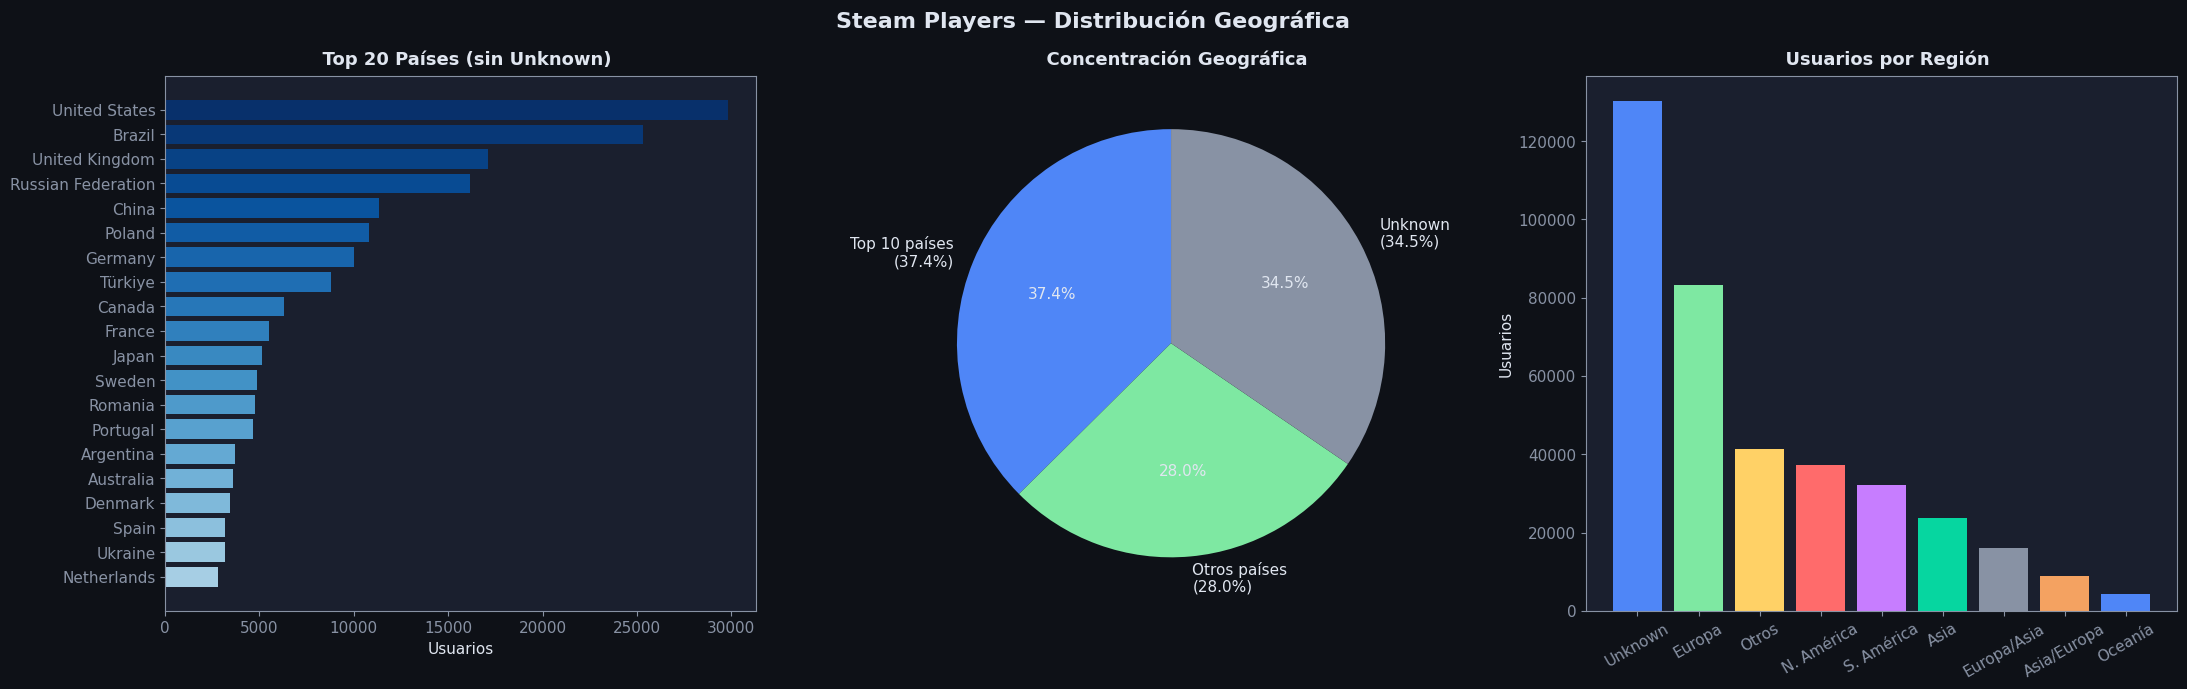

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Steam Players — Distribución Geográfica', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
top20 = df[df['country'] != 'Unknown']['country'].value_counts().head(20)
cmap = plt.cm.Blues(np.linspace(0.35, 1.0, len(top20)))
ax.barh(top20.index[::-1], top20.values[::-1], color=cmap)
ax.set_xlabel('Usuarios')
title_ax(ax, '  Top 20 Países (sin Unknown)')

ax = axes[1]
known   = df[df['country'] != 'Unknown']
top10_n = known['country'].value_counts().head(10).sum()
rest_n  = known['country'].value_counts().iloc[10:].sum()
unk_n   = (df['country'] == 'Unknown').sum()
ax.pie(
    [top10_n, rest_n, unk_n],
    labels=[f'Top 10 países\n({top10_n/len(df)*100:.1f}%)',
            f'Otros países\n({rest_n/len(df)*100:.1f}%)',
            f'Unknown\n({unk_n/len(df)*100:.1f}%)'],
    colors=[ACCENT1, ACCENT2, MUTED],
    startangle=90, textprops={'color': TEXT}, autopct='%1.1f%%'
)
title_ax(ax, '  Concentración Geográfica')

ax = axes[2]
continent_map = {
    'United States': 'N. América', 'Canada': 'N. América', 'Mexico': 'N. América',
    'Brazil': 'S. América', 'Argentina': 'S. América', 'Chile': 'S. América',
    'Colombia': 'S. América', 'Peru': 'S. América',
    'United Kingdom': 'Europa', 'Germany': 'Europa', 'France': 'Europa',
    'Poland': 'Europa', 'Russian Federation': 'Europa/Asia', 'Sweden': 'Europa',
    'Netherlands': 'Europa', 'Spain': 'Europa', 'Italy': 'Europa',
    'Ukraine': 'Europa', 'Finland': 'Europa', 'Norway': 'Europa',
    'Denmark': 'Europa', 'Czech Republic': 'Europa', 'Hungary': 'Europa',
    'Romania': 'Europa', 'Portugal': 'Europa', 'Austria': 'Europa',
    'Switzerland': 'Europa', 'Belgium': 'Europa', 'Greece': 'Europa',
    'China': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia',
    'India': 'Asia', 'Türkiye': 'Asia/Europa', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Indonesia': 'Asia', 'Vietnam': 'Asia',
    'Australia': 'Oceanía', 'New Zealand': 'Oceanía',
    'Unknown': 'Unknown',
}
df['continent'] = df['country'].map(continent_map).fillna('Otros')
cont_counts = df['continent'].value_counts()
colors_c = [ACCENT1, ACCENT2, ACCENT4, ACCENT3, '#c77dff', '#06d6a0', MUTED, '#f4a261']
ax.bar(cont_counts.index, cont_counts.values,
       color=colors_c[:len(cont_counts)])
ax.set_ylabel('Usuarios')
ax.tick_params(axis='x', rotation=30)
title_ax(ax, '  Usuarios por Región')

plt.tight_layout()
plt.show()

---
##  Análisis Temporal — Crecimiento de la Base de Usuarios

###  Hallazgos
- El crecimiento de cuentas fue sostenido desde 2003 hasta 2015, con un pico fuerte alrededor de 2014–2015.
- Desde 2016 en adelante se observa una caída progresiva en el número de cuentas nuevas. Esto no significa que Steam pierda usuarios, sino que este dataset captura solo ~424k perfiles públicos los perfiles más recientes tienden a ser privados.
- La hora de registro muestra dos picos: uno a media mañana y otro al final de la tarde (hora local del usuario), consistente con comportamiento de ocio.
- Los fines de semana concentran ligeramente más registros, lo que confirma que crear cuenta es un acto de ocio.

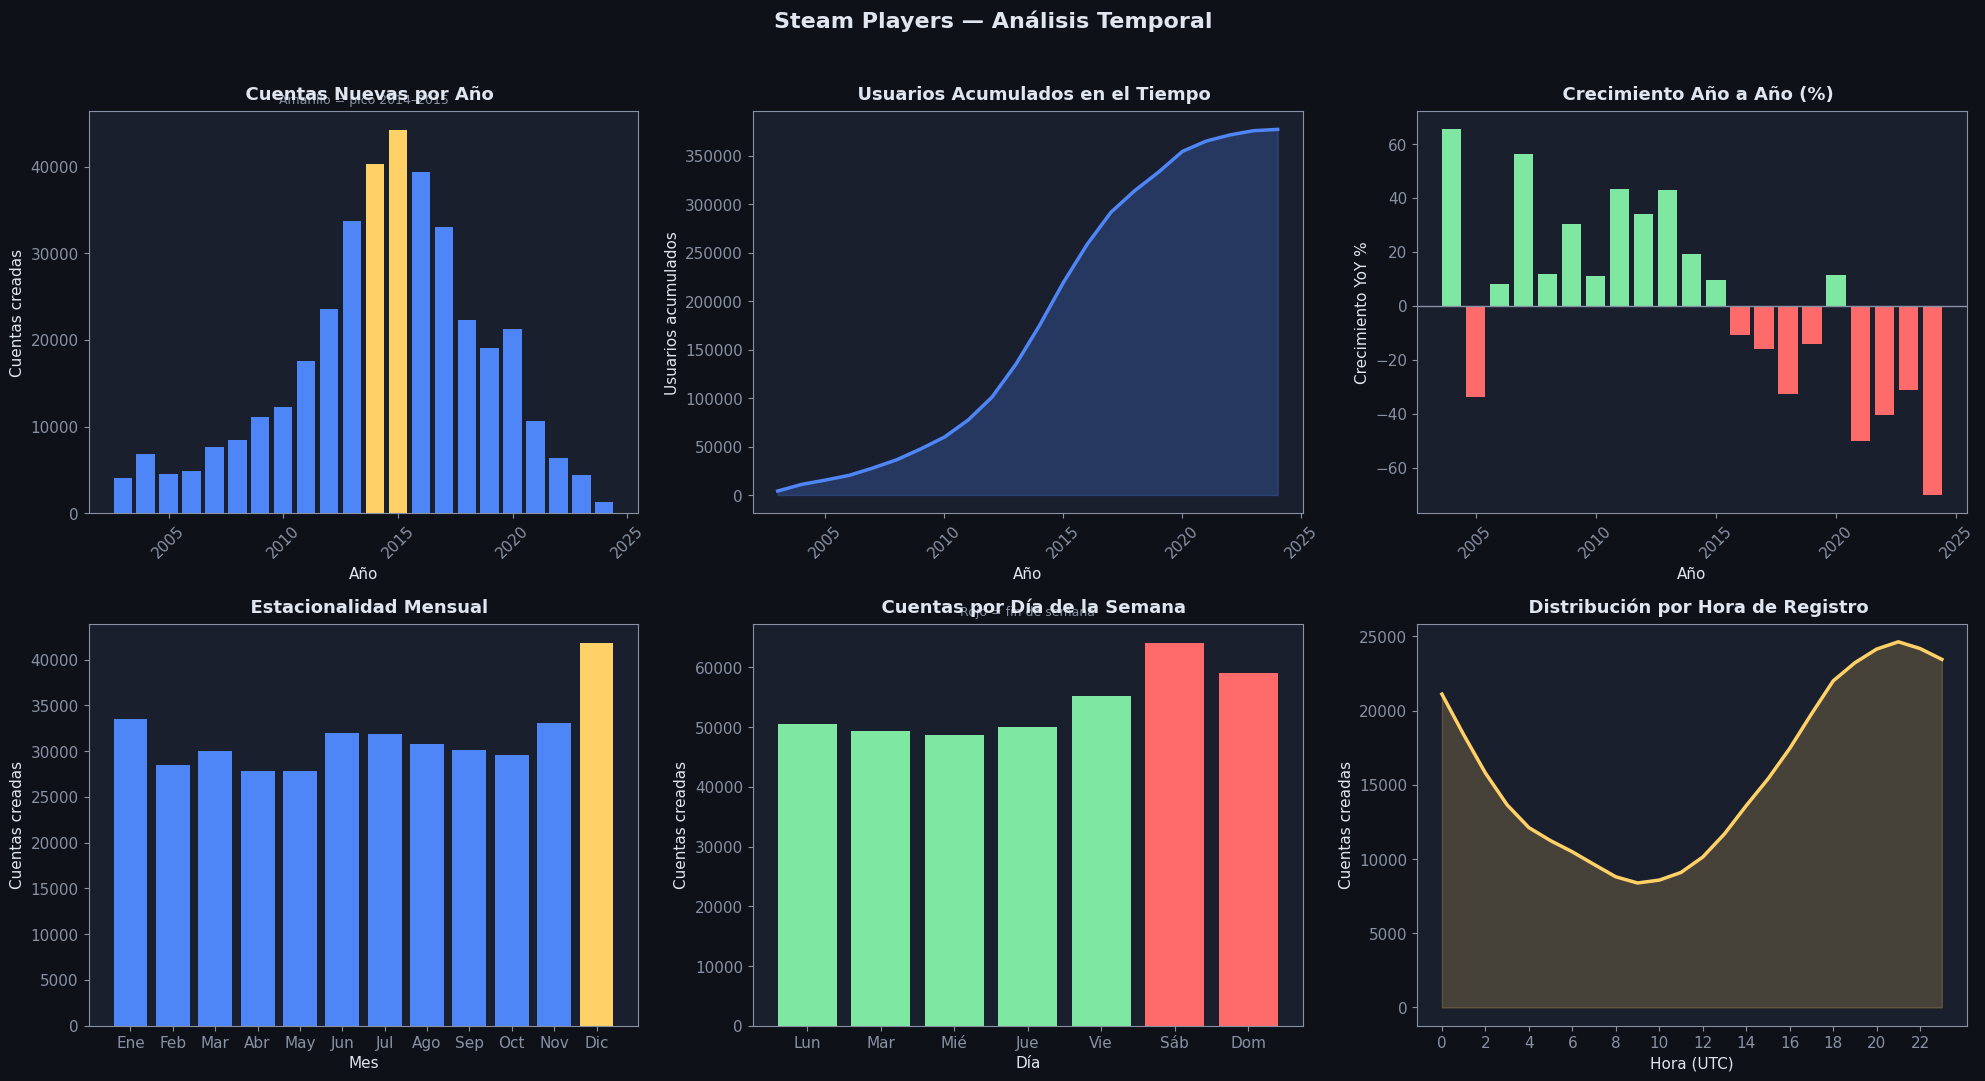

In [8]:
MONTH_NAMES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
DOW_NAMES   = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Steam Players — Análisis Temporal', fontsize=16, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
yr = df['created_year'].value_counts().sort_index()
yr = yr[(yr.index >= 2003) & (yr.index <= 2024)]
colors_yr = [ACCENT4 if y in [2014, 2015] else ACCENT1 for y in yr.index]
ax.bar(yr.index, yr.values, color=colors_yr, width=0.8)
ax.set_xlabel('Año'); ax.set_ylabel('Cuentas creadas')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Cuentas Nuevas por Año', 'Amarillo = pico 2014–2015')

ax = axes[0, 1]
cum = yr.cumsum()
ax.fill_between(cum.index, cum.values, alpha=0.25, color=ACCENT1)
ax.plot(cum.index, cum.values, color=ACCENT1, linewidth=2.5)
ax.set_xlabel('Año'); ax.set_ylabel('Usuarios acumulados')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Usuarios Acumulados en el Tiempo')

ax = axes[0, 2]
yoy = yr.pct_change().dropna() * 100
ax.bar(yoy.index, yoy.values,
       color=[ACCENT2 if v >= 0 else ACCENT3 for v in yoy.values], width=0.8)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('Año'); ax.set_ylabel('Crecimiento YoY %')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Crecimiento Año a Año (%)')

ax = axes[1, 0]
mo = df['created_month'].value_counts().sort_index()
ax.bar([MONTH_NAMES[m-1] for m in mo.index], mo.values,
       color=[ACCENT4 if v == mo.max() else ACCENT1 for v in mo.values])
ax.set_xlabel('Mes'); ax.set_ylabel('Cuentas creadas')
title_ax(ax, '  Estacionalidad Mensual')

ax = axes[1, 1]
dow = df['created_dow'].value_counts().sort_index()
ax.bar([DOW_NAMES[d] for d in dow.index], dow.values,
       color=[ACCENT3 if d >= 5 else ACCENT2 for d in dow.index])
ax.set_xlabel('Día'); ax.set_ylabel('Cuentas creadas')
title_ax(ax, '  Cuentas por Día de la Semana', 'Rojo = fin de semana')

ax = axes[1, 2]
hr = df['created_hour'].value_counts().sort_index()
ax.plot(hr.index, hr.values, color=ACCENT4, linewidth=2.5)
ax.fill_between(hr.index, hr.values, alpha=0.2, color=ACCENT4)
ax.set_xlabel('Hora (UTC)'); ax.set_ylabel('Cuentas creadas')
ax.set_xticks(range(0, 24, 2))
title_ax(ax, '  Distribución por Hora de Registro')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Cruce: Geografía × Tiempo

###  Hallazgos
- EE.UU. fue el país dominante en los primeros años de Steam (2003–2012), pero su proporción relativa ha bajado a medida que la plataforma se internacionalizó.
- Brasil tuvo su mayor entrada de usuarios entre 2013 y 2016, coincidiendo con promociones agresivas de Steam en Latinoamérica.
- China muestra un crecimiento atípicamente tardío (post-2015), posiblemente ligado a la habilitación de pagos locales en Steam.
- Los países con `Unknown` están distribuidos en todos los años, no son un artefacto de una época particular.

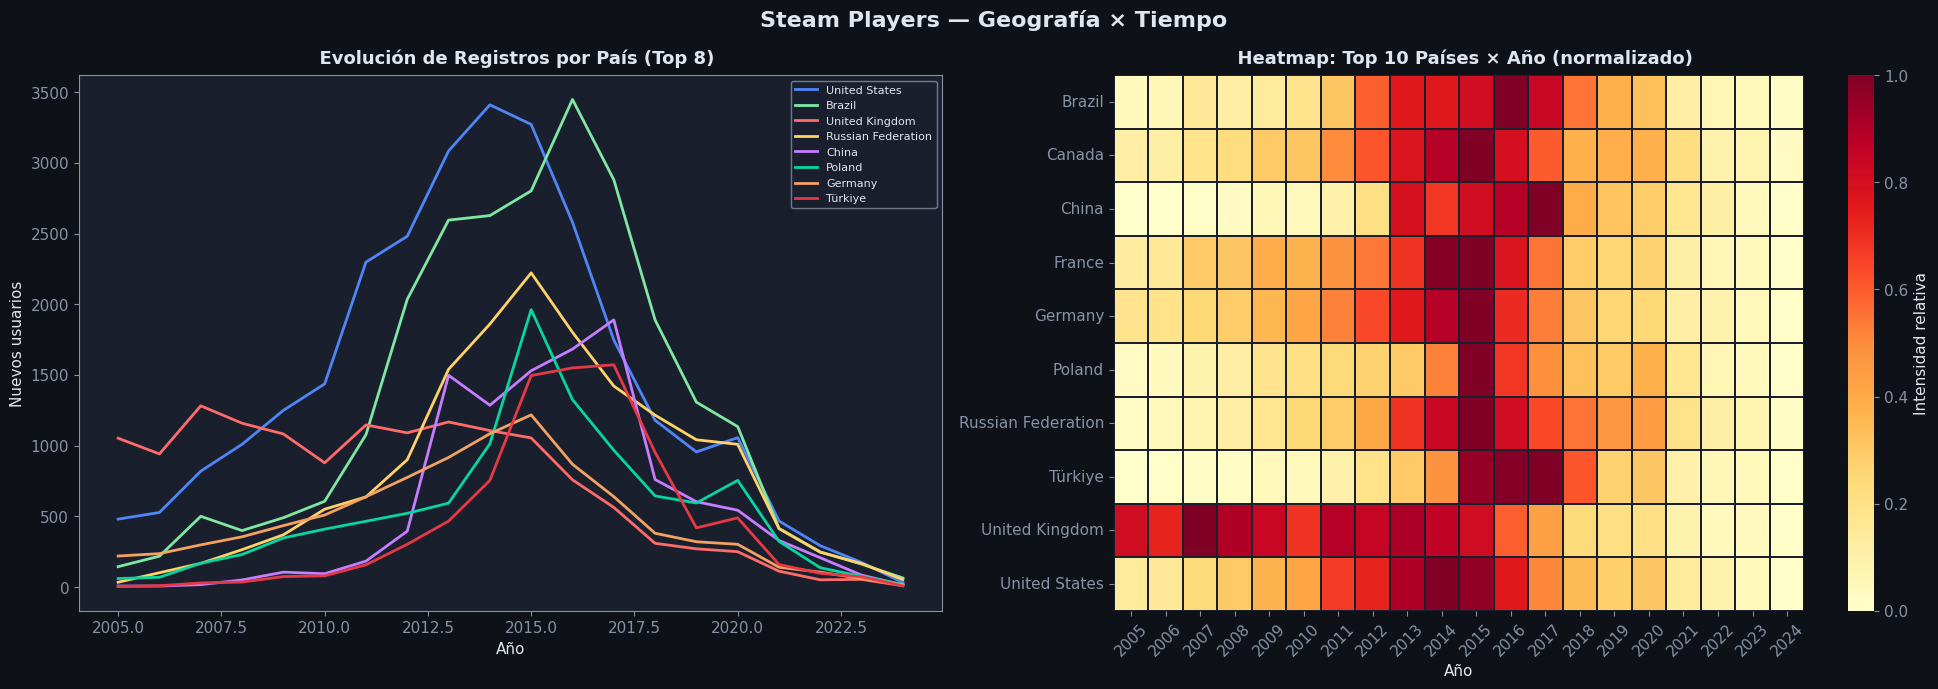

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Steam Players — Geografía × Tiempo', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
top8_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(8).index.tolist()
df_top = df[df['country'].isin(top8_countries)]
pivot = df_top.groupby(['created_year', 'country']).size().unstack(fill_value=0)
pivot = pivot[(pivot.index >= 2005) & (pivot.index <= 2024)]
colors_t = [ACCENT1, ACCENT2, ACCENT3, ACCENT4, '#c77dff', '#06d6a0', '#f4a261', '#e63946']
for i, c in enumerate(top8_countries):
    if c in pivot.columns:
        ax.plot(pivot.index, pivot[c], label=c, color=colors_t[i], linewidth=2)
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT, loc='upper right')
ax.set_xlabel('Año'); ax.set_ylabel('Nuevos usuarios')
title_ax(ax, '  Evolución de Registros por País (Top 8)')

ax = axes[1]
top10_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10).index.tolist()
df_h = df[df['country'].isin(top10_countries)]
heat = df_h.groupby(['created_year', 'country']).size().unstack(fill_value=0)
heat = heat[(heat.index >= 2005) & (heat.index <= 2024)]
heat_norm = heat.div(heat.max()).round(2)  
sns.heatmap(heat_norm.T, ax=ax, cmap='YlOrRd', linewidths=0.3,
            linecolor='#1a1f2e', cbar_kws={'label': 'Intensidad relativa'})
ax.set_xlabel('Año'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Heatmap: Top 10 Países × Año (normalizado)')

plt.tight_layout()
plt.show()

---
## Análisis de Cohortes y Diversidad

###  Hallazgos
- El índice de diversidad geográfica (número efectivo de países) ha crecido año a año, especialmente desde 2010  Steam se ha vuelto cada vez más global.
- Las cohortes de 2013–2015 son las más grandes en términos de usuarios, lo que las hace las más representativas del dataset.
- La proporción de usuarios con país `Unknown` se mantiene relativamente estable a lo largo de los años, lo que sugiere que no es un problema de calidad de datos reciente sino una constante estructural de la plataforma.

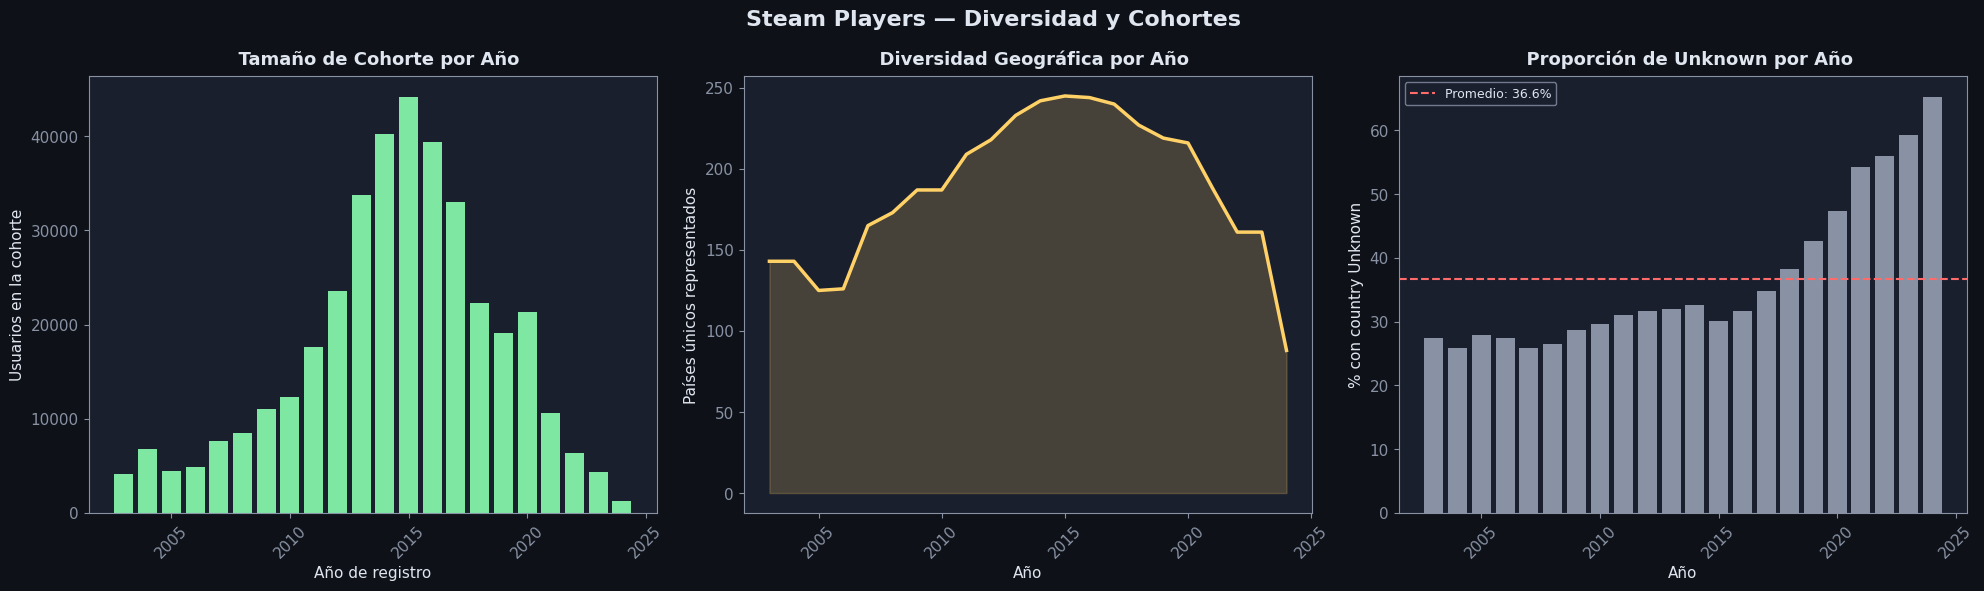

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Steam Players — Diversidad y Cohortes', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
cohort_size = df.groupby('created_year').size()
cohort_size = cohort_size[(cohort_size.index >= 2003) & (cohort_size.index <= 2024)]
ax.bar(cohort_size.index, cohort_size.values, color=ACCENT2, width=0.8)
ax.set_xlabel('Año de registro'); ax.set_ylabel('Usuarios en la cohorte')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Tamaño de Cohorte por Año')

ax = axes[1]
known_df = df[df['country'] != 'Unknown']
diversity = known_df.groupby('created_year')['country'].nunique()
diversity = diversity[(diversity.index >= 2003) & (diversity.index <= 2024)]
ax.plot(diversity.index, diversity.values, color=ACCENT4, linewidth=2.5)
ax.fill_between(diversity.index, diversity.values, alpha=0.2, color=ACCENT4)
ax.set_xlabel('Año'); ax.set_ylabel('Países únicos representados')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Diversidad Geográfica por Año')

ax = axes[2]
unk_ratio = df.groupby('created_year').apply(
    lambda x: (x['country'] == 'Unknown').mean() * 100
).reset_index()
unk_ratio.columns = ['year', 'pct_unknown']
unk_ratio = unk_ratio[(unk_ratio['year'] >= 2003) & (unk_ratio['year'] <= 2024)]
ax.bar(unk_ratio['year'], unk_ratio['pct_unknown'], color=MUTED, width=0.8)
ax.axhline(unk_ratio['pct_unknown'].mean(), color=ACCENT3, linewidth=1.5,
           linestyle='--', label=f"Promedio: {unk_ratio['pct_unknown'].mean():.1f}%")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Año'); ax.set_ylabel('% con country Unknown')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Proporción de Unknown por Año')

plt.tight_layout()
plt.show()

---
##  Dataset limpio final


In [11]:
print("═" * 50)
print("  RESUMEN DEL DATASET LIMPIO — players")
print("═" * 50)
print(f"  Filas originales    : {df_raw.shape[0]:>10,}")
print(f"  Filas eliminadas    : {df_raw.shape[0] - len(df):>10,}  (created NaN)")
print(f"  Filas finales       : {len(df):>10,}")
print(f"  Country 'Unknown'   : {(df['country']=='Unknown').sum():>10,}  ({(df['country']=='Unknown').mean()*100:.1f}%)")
print(f"  Rango de fechas     :  {df['created'].min().date()} → {df['created'].max().date()}")
print(f"  Países únicos       : {df['country'].nunique():>10,}  (incluye 'Unknown')")
print(f"  Faltantes restantes : {df.isnull().sum().sum():>10,}")
print("═" * 50)
df.head(5)

══════════════════════════════════════════════════
  RESUMEN DEL DATASET LIMPIO — players
══════════════════════════════════════════════════
  Filas originales    :    424,683
  Filas eliminadas    :     47,669  (created NaN)
  Filas finales       :    377,014
  Country 'Unknown'   :    130,199  (34.5%)
  Rango de fechas     :  2003-09-11 → 2025-01-07
  Países únicos       :        250  (incluye 'Unknown')
  Faltantes restantes :          0
══════════════════════════════════════════════════


,playerid,country,created,created_year,created_month,created_dow,created_hour,is_private,continent
0,76561198287452552,Brazil,2016-03-02 06:14:20,2016,3,2,6,False,S. América
1,76561198040436563,Israel,2011-04-10 17:10:06,2011,4,6,17,False,Otros
2,76561198049686270,Unknown,2011-09-28 21:43:59,2011,9,2,21,False,Unknown
3,76561198155814250,Kazakhstan,2014-09-24 19:52:47,2014,9,2,19,False,Otros
4,76561198119605821,Unknown,2013-12-26 00:25:50,2013,12,3,0,True,Unknown


---
## Exportar dataset limpio


**Archivo generado:**
- `players_clean.csv` una fila por usuario: `playerid`, `country`, `created`, `account_age_years`, `is_private`, `continent`


In [12]:
import numpy as np

df['account_age_years'] = (
    (pd.Timestamp.now() - df['created']).dt.days / 365.25
).round(2)

cols_players = ['playerid','country','created','account_age_years','is_private']
if 'continent' in df.columns:
    cols_players.append('continent')

df[cols_players].to_csv('Datos/players_clean.csv', index=False)

print(f'players_clean.csv : {len(df):,} usuarios, {len(cols_players)} columnas')
print(f'  is_private=True : {df["is_private"].sum():,}  ({df["is_private"].mean()*100:.1f}%)')
df[cols_players].head(3)


players_clean.csv : 377,014 usuarios, 6 columnas
  is_private=True : 200,483  (53.2%)


,playerid,country,created,account_age_years,is_private,continent
0,76561198287452552,Brazil,2016-03-02 06:14:20,10.23,False,S. América
1,76561198040436563,Israel,2011-04-10 17:10:06,15.13,False,Otros
2,76561198049686270,Unknown,2011-09-28 21:43:59,14.66,False,Unknown


---
##  Conclusiones


### Próximos pasos
- **Feature para regresión:** usar `is_private`, `country` (top-N + "Other") y `account_age_years` como features del usuario.
- **Cruzar con `purchased_games`:** ¿los usuarios de qué país tienen más juegos en biblioteca?
- **Cruzar con `history`:** ¿hay correlación entre antigüedad de cuenta (`created`) y número de logros desbloqueados?
- **Cruzar con `reviews`:** ¿qué países generan más reseñas? ¿Hay sesgo geográfico en el ratio positivo/negativo?